# Zero Trust Authentication using Machine Learning

## Project Overview
This project builds an intelligent Zero Trust Authentication system that evaluates login attempts using contextual and behavioral signals instead of relying only on passwords.

The system predicts whether a login attempt should be:

- **ALLOW** → low-risk access granted  
- **MFA** → additional verification required  
- **BLOCK** → suspicious access denied  

---

## Dataset
The model is trained using the **RBA (Risk-Based Authentication) Dataset**, containing login events with network, device, geolocation, and attack indicators.

---

## Objectives
1. Build a clean ML pipeline for login risk scoring  
2. Engineer meaningful security features  
3. Compare classification models  
4. Generate interpretable risk scores  
5. Export production-ready model files for backend integration  

---

## Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib / Seaborn
- Scikit-learn
- Joblib

---

## Workflow
1. Data Loading  
2. Data Cleaning  
3. Exploratory Data Analysis  
4. Feature Engineering  
5. Model Training  
6. Evaluation  
7. Threshold Tuning  
8. Model Export

Import Libraries & Configure Notebook

#  Import Libraries & Configure Global Settings

## Objective
This cell imports all required Python libraries for data processing, visualization, machine learning, evaluation, and model persistence. It also configures notebook-wide styling settings for cleaner outputs and professional charts.

## Sections Covered
1. Core Python Libraries  
2. Data Visualization Libraries  
3. Utility Tools  
4. Machine Learning Modules  
5. Model Saving Utilities  
6. Notebook Display Configuration

In [1]:


# -------------------------------
# Core Python Libraries
# -------------------------------

import os
# Used for file and folder operations
# Example: checking if dataset path exists, creating directories

import warnings
# Used to manage warning messages generated by libraries

import numpy as np
# NumPy provides fast numerical operations and array handling

import pandas as pd
# Pandas is used for loading, cleaning, transforming,
# and analyzing tabular datasets


# -------------------------------
# Data Visualization Libraries
# -------------------------------

import matplotlib.pyplot as plt
# Main plotting library for charts, graphs, histograms, etc.

import seaborn as sns
# Built on matplotlib, used for cleaner statistical plots


# -------------------------------
# Utility Library
# -------------------------------

from tqdm import tqdm
# Adds progress bars for long-running loops
# Helpful when reading large datasets in chunks


# -------------------------------
# Machine Learning Utilities
# -------------------------------

from sklearn.model_selection import train_test_split
# Splits data into training and testing sets

from sklearn.preprocessing import StandardScaler
# Standardizes features (mean=0, std=1)
# Important for algorithms like Logistic Regression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# classification_report     -> precision, recall, f1-score
# confusion_matrix          -> TP, TN, FP, FN summary
# roc_auc_score             -> probability ranking quality
# roc_curve                 -> ROC graph points
# precision_recall_curve    -> PR curve points
# average_precision_score   -> PR summary score


# -------------------------------
# Machine Learning Models
# -------------------------------

from sklearn.linear_model import LogisticRegression
# Linear baseline classifier

from sklearn.ensemble import RandomForestClassifier
# Powerful tree-based ensemble model

from sklearn.calibration import CalibratedClassifierCV
# Improves probability outputs of models
# Useful for meaningful risk scores


# -------------------------------
# Model Persistence
# -------------------------------

import joblib
# Saves trained models to .pkl files
# Used later in backend deployment


# -------------------------------
# Global Notebook Styling
# -------------------------------

warnings.filterwarnings("ignore")
# Hides non-critical warnings for cleaner notebook output

sns.set_style("whitegrid")
# Applies clean grid background to charts

plt.rcParams["figure.figsize"] = (10, 5)
# Default chart size = width 10, height 5

plt.rcParams["axes.titlesize"] = 14
# Default chart title font size

plt.rcParams["axes.labelsize"] = 12
# Default axis label font size

print("Libraries imported successfully")
# Confirms all imports executed correctly

Libraries imported successfully


#  Mount Google Drive & Validate Dataset Path

## Objective
This cell connects the notebook to Google Drive, defines all required file paths, creates an output directory for saved models, and verifies that the dataset file is available before processing begins.

## Why This Step Is Important
- Allows access to datasets stored in Google Drive  
- Centralizes all file paths in one place  
- Prevents runtime errors caused by missing files  
- Creates a dedicated folder for exported models

In [2]:

# ----------------------------------
# Step 1: Connect Google Drive
# ----------------------------------

from google.colab import drive
# Imports Google Colab Drive utility

drive.mount('/content/drive')
# Mounts Google Drive so notebook can access files
# After running, authorization will be required


# ----------------------------------
# Step 2: Define File Paths
# ----------------------------------

DATA_PATH = "/content/drive/MyDrive/rba-dataset.csv"
# Main raw dataset file

SAMPLE_PATH = "/content/drive/MyDrive/sample_100k2.csv"
# Output path for sampled dataset created later

MODEL_DIR = "/content/drive/MyDrive/zta_models"
# Folder where trained models and artifacts will be saved


# ----------------------------------
# Step 3: Create Output Directory
# ----------------------------------

os.makedirs(MODEL_DIR, exist_ok=True)
# Creates the folder if it does not exist
# exist_ok=True prevents error if folder already exists


# ----------------------------------
# Step 4: Validate Dataset Presence
# ----------------------------------

print("Dataset exists:", os.path.exists(DATA_PATH))
# Checks whether dataset file exists
# Returns True or False


# ----------------------------------
# Step 5: Show Dataset Size
# ----------------------------------

if os.path.exists(DATA_PATH):
    # Run this block only if file exists

    file_size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
    # Gets file size in bytes and converts to MB

    print(f"Dataset size: {file_size_mb:.2f} MB")
    # Displays readable dataset size

else:
    # Run this block if file is missing

    print("Dataset not found. Please check path.")
    # Clear error message for debugging

Mounted at /content/drive
Dataset exists: True
Dataset size: 8633.53 MB


#  Estimate Class Distribution from Large Dataset

## Objective
This cell scans the complete dataset in chunks to estimate the number of attack and normal login records without loading the entire file into memory.

## Why This Step Is Important
- Large datasets may not fit into RAM
- Helps detect class imbalance
- Determines how many positive and negative rows to include in the sample dataset
- Prepares for stratified sampling in the next step

In [3]:


# ----------------------------------
# Step 1: Global Configuration
# ----------------------------------

CHUNK_SIZE = 200_000
# Number of rows loaded at a time from the CSV file

TARGET_ROWS = 100_000
# Desired size of final sampled dataset

RANDOM_STATE = 42
# Fixed seed for reproducibility
# Ensures same random results every run


# ----------------------------------
# Step 2: Convert Text Values to Boolean
# ----------------------------------

def truth(x):
    """
    Converts mixed text labels into True/False.
    Handles values like:
    1, true, yes, y, t
    """

    if pd.isna(x):
        return False
        # Missing values treated as False

    return str(x).strip().lower() in (
        "1", "true", "yes", "y", "t"
    )
    # Normalize text and check if it means True


# ----------------------------------
# Step 3: Create Final Attack Label
# ----------------------------------

def compute_attack_label(chunk):
    """
    Combines two security indicators:
    1. Is Attack IP
    2. Is Account Takeover

    If either is True -> attack_label = 1
    Else -> attack_label = 0
    """

    attack_ip = chunk["Is Attack IP"].apply(truth)
    # Convert attack IP column into boolean values

    takeover = chunk["Is Account Takeover"].apply(truth)
    # Convert account takeover column into boolean values

    return (attack_ip | takeover).astype(int)
    # Logical OR:
    # True if any one is suspicious
    # Convert result into 1 / 0


# ----------------------------------
# Step 4: Begin Dataset Scan
# ----------------------------------

print("🔍 Scanning dataset to estimate class distribution...")


# ----------------------------------
# Step 5: Initialize Counters
# ----------------------------------

pos_count, neg_count = 0, 0
# pos_count = attack rows
# neg_count = normal rows


# ----------------------------------
# Step 6: Read Dataset in Chunks
# ----------------------------------

for chunk in tqdm(
    pd.read_csv(
        DATA_PATH,
        chunksize=CHUNK_SIZE,
        dtype=str
    )
):
    # Loads only 200k rows at a time

    if "index" in chunk.columns:
        chunk = chunk.drop(columns=["index"])
        # Removes unwanted extra index column if present

    labels = compute_attack_label(chunk)
    # Generate labels for current chunk

    pos_count += int(labels.sum())
    # Add attack rows count

    neg_count += int((labels == 0).sum())
    # Add normal rows count


# ----------------------------------
# Step 7: Compute Sampling Targets
# ----------------------------------

total = pos_count + neg_count
# Total rows scanned

pos_target = int(
    TARGET_ROWS * (pos_count / total)
)
# Number of positive rows needed in sample
# Preserves original class ratio

neg_target = TARGET_ROWS - pos_target
# Remaining rows become negative sample count


# ----------------------------------
# Step 8: Build Summary Table
# ----------------------------------

summary_df = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Positive Rows",
        "Negative Rows",
        "Target Positive Sample",
        "Target Negative Sample"
    ],

    "Value": [
        total,
        pos_count,
        neg_count,
        pos_target,
        neg_target
    ]
})


# ----------------------------------
# Step 9: Display Results
# ----------------------------------

display(summary_df)
# Shows final class distribution summary

🔍 Scanning dataset to estimate class distribution...


157it [05:51,  2.24s/it]


,Metric,Value
0,Total Rows,31269264
1,Positive Rows,3097041
2,Negative Rows,28172223
3,Target Positive Sample,9904
4,Target Negative Sample,90096


#  Build and Save Stratified Sample Dataset

## Objective
This cell creates a smaller working dataset by selecting positive (attack) and negative (normal) rows while preserving the original class ratio calculated in the previous step.

## Why This Step Is Important
- Reduces training time significantly
- Keeps dataset manageable for experimentation
- Preserves real-world class distribution
- Saves the sample for reuse in later cells

In [7]:

# ----------------------------------
# Step 1: Start Sampling Process
# ----------------------------------

print("📦 Creating stratified sample dataset...")


# ----------------------------------
# Step 2: Initialize Counters
# ----------------------------------

remaining_pos, remaining_neg = pos_target, neg_target
# Number of positive and negative rows still needed

frames = []
# List to temporarily store sampled chunks


# ----------------------------------
# Step 3: Read Dataset in Chunks
# ----------------------------------

for chunk in tqdm(
    pd.read_csv(
        DATA_PATH,
        chunksize=CHUNK_SIZE,
        dtype=str
    )
):

    if "index" in chunk.columns:
        chunk = chunk.drop(columns=["index"])
        # Remove unnecessary index column if present


    # ----------------------------------
    # Step 4: Create Labels for Chunk
    # ----------------------------------

    chunk["attack_label"] = compute_attack_label(chunk)
    # Add target column:
    # 1 = attack
    # 0 = normal


    # ----------------------------------
    # Step 5: Split by Class
    # ----------------------------------

    pos_rows = chunk[chunk["attack_label"] == 1]
    # Attack rows in current chunk

    neg_rows = chunk[chunk["attack_label"] == 0]
    # Normal rows in current chunk


    # ----------------------------------
    # Step 6: Sample Positive Rows
    # ----------------------------------

    if remaining_pos > 0 and len(pos_rows) > 0:

        take = min(remaining_pos, len(pos_rows))
        # Number of rows we can safely take

        frames.append(
            pos_rows.sample(
                n=take,
                random_state=RANDOM_STATE
            )
        )
        # Randomly sample attack rows
        # Append to list

        remaining_pos -= take
        # Reduce pending positive count


    # ----------------------------------
    # Step 7: Sample Negative Rows
    # ----------------------------------

    if remaining_neg > 0 and len(neg_rows) > 0:

        take = min(remaining_neg, len(neg_rows))

        frames.append(
            neg_rows.sample(
                n=take,
                random_state=RANDOM_STATE
            )
        )
        # Randomly sample normal rows

        remaining_neg -= take
        # Reduce pending negative count


    # ----------------------------------
    # Step 8: Stop Early if Done
    # ----------------------------------

    if remaining_pos <= 0 and remaining_neg <= 0:
        break
        # Exit loop once enough rows collected


# ----------------------------------
# Step 9: Merge All Sampled Parts
# ----------------------------------

sample_df = pd.concat(
    frames,
    ignore_index=True
)
# Combine all sampled chunks into one DataFrame


# ----------------------------------
# Step 10: Shuffle Dataset
# ----------------------------------

sample_df = sample_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# frac=1 means shuffle all rows
# reset_index gives clean row numbers


# ----------------------------------
# Step 11: Save Sample to CSV
# ----------------------------------

sample_df.to_csv(
    SAMPLE_PATH,
    index=False
)
# Save final dataset for reuse


# ----------------------------------
# Step 12: Final Status Output
# ----------------------------------

print("✅ Stratified sample saved successfully")
print("Saved Path:", SAMPLE_PATH)
print("Final Shape:", sample_df.shape)

display(
    sample_df["attack_label"]
    .value_counts()
    .to_frame("Count")
)
# Shows class counts in final sample

📦 Creating stratified sample dataset...


0it [00:04, ?it/s]


✅ Stratified sample saved successfully
Saved Path: /content/drive/MyDrive/sample_100k2.csv
Final Shape: (100000, 16)


,Count
attack_label,
0,90096
1,9904


#  Create Balanced Training Dataset

## Objective
This cell creates a balanced dataset for model training by equalizing the number of attack and normal login records.

## Why This Step Is Important
The stratified sample still contained severe class imbalance. A balanced dataset helps machine learning models learn both classes more effectively.

## Technique Used
Random Undersampling of the majority class:
- Keep all positive (attack) rows
- Randomly select the same number of negative (normal) rows

In [8]:

# ----------------------------------
# Step 1: Load Stratified Sample
# ----------------------------------

sample_df = pd.read_csv(SAMPLE_PATH)
# Load the 100k sample created earlier


# ----------------------------------
# Step 2: Separate Both Classes
# ----------------------------------

positive_df = sample_df[
    sample_df["attack_label"] == 1
].copy()
# All attack rows

negative_df = sample_df[
    sample_df["attack_label"] == 0
].copy()
# All normal rows


# ----------------------------------
# Step 3: Show Original Distribution
# ----------------------------------

print("Original Sample Distribution:")

display(
    sample_df["attack_label"]
    .value_counts()
    .to_frame("Count")
)
# Displays class imbalance before balancing


# ----------------------------------
# Step 4: Randomly Undersample Negatives
# ----------------------------------

balanced_neg = negative_df.sample(
    n=len(positive_df),
    random_state=RANDOM_STATE
)

# Select exactly same number of negative rows
# as positive rows


# ----------------------------------
# Step 5: Merge Both Classes
# ----------------------------------

balanced_df = pd.concat(
    [positive_df, balanced_neg],
    axis=0
)
# Combine positive + selected negative rows


# ----------------------------------
# Step 6: Shuffle Final Dataset
# ----------------------------------

balanced_df = balanced_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# Randomize row order
# reset_index gives clean numbering


# ----------------------------------
# Step 7: Save Balanced Dataset
# ----------------------------------

BALANCED_PATH = "/content/drive/MyDrive/balanced_sample.csv"
# Output path for balanced training file

balanced_df.to_csv(
    BALANCED_PATH,
    index=False
)
# Save dataset as CSV


# ----------------------------------
# Step 8: Final Output Summary
# ----------------------------------

print("\nBalanced dataset created successfully")
print("Saved Path:", BALANCED_PATH)
print("Final Shape:", balanced_df.shape)

display(
    balanced_df["attack_label"]
    .value_counts()
    .to_frame("Count")
)
# Verify both classes are equal

Original Sample Distribution:


,Count
attack_label,
0,90096
1,9904



Balanced dataset created successfully
Saved Path: /content/drive/MyDrive/balanced_sample.csv
Final Shape: (19808, 16)


,Count
attack_label,
1,9904
0,9904


# Cell 5A — Load Balanced Dataset and Preview Structure

## Objective
This cell loads the balanced dataset created in the previous step and performs an initial structural inspection.

## Why This Step Is Important
Before preprocessing and model training, it is essential to verify:

- dataset dimensions  
- number of columns  
- available feature names  
- sample records  

This ensures the dataset was saved and loaded correctly.

In [9]:
# ==========================================
# CELL 5A: Load Balanced Dataset & Preview
# ==========================================

# Step 1: Load balanced dataset
df = pd.read_csv(BALANCED_PATH)
# Reads the saved balanced CSV file into a DataFrame
# This DataFrame will be used for further preprocessing and modeling

# Step 2: Display dataset dimensions
print("Dataset Shape:", df.shape)
# Returns (rows, columns)

print("Number of Columns:", df.shape[1])
# Returns only total number of columns

# Step 3: Display column names
print("\nColumn Names:")
display(pd.DataFrame({"Columns": df.columns}))
# Converts column names into a table for cleaner viewing

# Step 4: Preview first records
print("\nFirst 5 Rows:")
display(df.head())
# Shows first 5 rows to inspect values and structure

Dataset Shape: (19808, 16)
Number of Columns: 16

Column Names:


,Columns
0,Login Timestamp
1,User ID
2,Round-Trip Time [ms]
3,IP Address
4,Country
5,Region
6,City
7,ASN
8,User Agent String
9,Browser Name and Version



First 5 Rows:


,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,attack_label
0,2020-02-05 16:48:08.613,-4324475583306591935,NaN,209.236.117.142,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 14_2_1 like...,Snapchat 11.8.1,iOS 14.2.1,mobile,False,True,False,1
1,2020-02-04 19:37:58.785,-4324475583306591935,NaN,10.0.0.89,US,Kansas,Logan,398986,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 63.0.3239,Android 4.1,mobile,False,True,False,1
2,2020-02-03 16:20:37.198,-4324475583306591935,NaN,209.236.123.147,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 14_2_1 lik...,Firefox 20.0.0.1681,iOS 14.2.1,mobile,False,True,False,1
3,2020-02-04 15:19:56.742,-4324475583306591935,NaN,38.135.39.107,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 14_2_1 lik...,Firefox 20.0.0.1689,iOS 14.2.1,mobile,False,True,False,1
4,2020-02-04 01:39:20.603,8028067747891309871,NaN,193.242.213.164,PL,-,-,50121,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0.0.1618,iOS 11.2.6,mobile,True,True,False,1


# Cell 5B — Target Distribution Visualization

## Objective
This cell visualizes the distribution of the target variable `attack_label` to confirm that the balanced dataset contains equal representation of both classes.

## Why This Step Is Important
Checking class distribution before training is essential because:

- imbalanced classes can bias model predictions  
- balanced classes improve fair learning  
- charts make dataset quality easy to interpret  

## Target Meaning
- **0** → Normal Login  
- **1** → Attack Login

## Outputs Generated
1. Bar chart of class counts  
2. Percentage table of each class

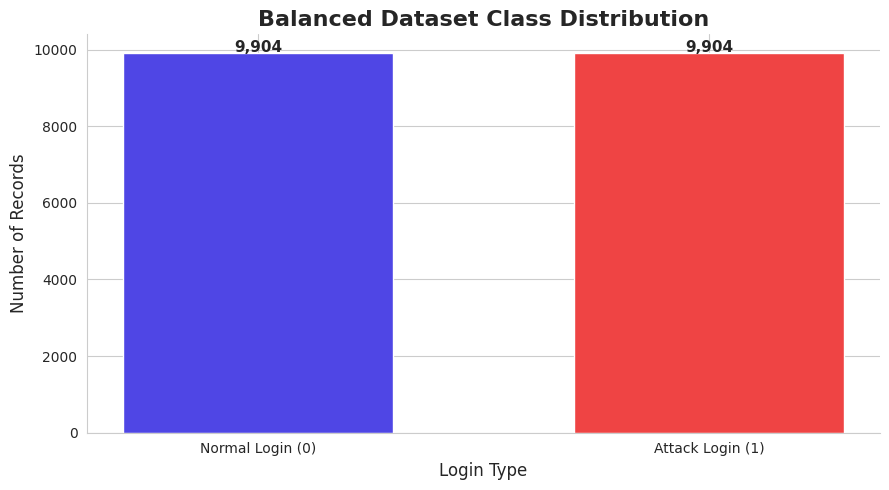

Class Percentages:


,%
attack_label,
1,50.0
0,50.0


In [10]:
# ==========================================
# CELL 5B: Beautiful Target Distribution Chart
# ==========================================

# Step 1: Count target classes
class_counts = df["attack_label"].value_counts().sort_index()

# Step 2: Set style
sns.set_style("whitegrid")

# Step 3: Create chart
fig, ax = plt.subplots(figsize=(9,5))

colors = ["#4F46E5", "#EF4444"]  # Indigo, Red

bars = ax.bar(
    ["Normal Login (0)", "Attack Login (1)"],
    class_counts.values,
    color=colors,
    width=0.6
)

# Step 4: Titles and labels
ax.set_title("Balanced Dataset Class Distribution", fontsize=16, fontweight="bold")
ax.set_xlabel("Login Type", fontsize=12)
ax.set_ylabel("Number of Records", fontsize=12)

# Step 5: Add values above bars
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 40,
        f"{int(h):,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Step 6: Improve look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Step 7: Percentage table
print("Class Percentages:")
display(
    (df["attack_label"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("%")
)

# Cell 6A — Missing Values Audit

## Objective
This cell checks the dataset for missing values and summarizes which columns contain incomplete data.

## Why This Step Is Important
Missing values can reduce model performance and cause preprocessing errors. Identifying them early helps us choose suitable cleaning strategies such as imputation or column removal.

## Outputs Generated
1. Total number of columns with missing values  
2. Summary table with:
   - column name  
   - missing count  
   - missing percentage

In [12]:
# ==========================================
# CELL 6A: Missing Values Audit
# ==========================================

# Step 1: Count missing values in each column
missing_counts = df.isnull().sum()

# Step 2: Keep only columns with missing data
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Step 3: Show number of affected columns
print("Columns with Missing Values:", len(missing_counts))

# Step 4: Build summary table
if len(missing_counts) > 0:
    missing_df = pd.DataFrame({
        "Column": missing_counts.index,
        "Missing Count": missing_counts.values,
        "Missing %": (missing_counts.values / len(df) * 100).round(2)
    })

    display(missing_df)
    # Displays clean missing value report

else:
    print("No missing values found in the dataset.")

Columns with Missing Values: 4


,Column,Missing Count,Missing %
0,Round-Trip Time [ms],19277,97.32
1,Region,7,0.04
2,City,3,0.02
3,Device Type,1,0.01


# Cell 6B — Missing Values Visualization

## Objective
This cell visualizes missing values across dataset columns using a horizontal bar chart.

## Why This Step Is Important
Visual charts make it easier to identify columns with severe data quality issues and prioritize cleaning decisions.

## Design Goals
- modern academic styling  
- clear labels  
- readable values  
- professional presentation quality

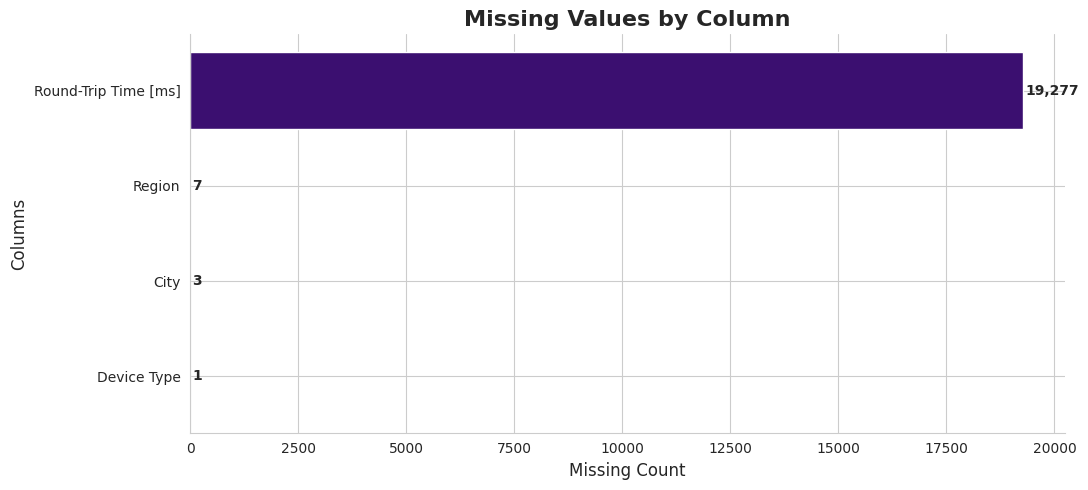

In [14]:


if len(missing_counts) > 0:

    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(11,5))

    # Soft gradient-style colors
    colors = sns.color_palette("magma", len(missing_counts))

    bars = ax.barh(
        missing_counts.index,
        missing_counts.values,
        color=colors
    )

    # Titles and labels
    ax.set_title(
        "Missing Values by Column",
        fontsize=16,
        fontweight="bold"
    )
    ax.set_xlabel("Missing Count", fontsize=12)
    ax.set_ylabel("Columns", fontsize=12)

    # Highest bar on top
    ax.invert_yaxis()

    # Add values at end of bars
    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + 50,
            bar.get_y() + bar.get_height()/2,
            f"{int(w):,}",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    # Clean borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

else:
    print("No chart generated because dataset has no missing values.")

# Cell 7A — Imputation of Missing RTT Values

## Objective
This cell handles missing values in the `Round-Trip Time [ms]` feature by replacing them with the median value.

## Why This Step Is Important
RTT is an important network behavior feature, but many rows contain missing values. Instead of dropping records, median imputation preserves data while reducing the effect of outliers.

## Why Median Instead of Mean?
The RTT distribution contains extreme values, so the median is more robust and stable than the mean.

## Outputs Generated
1. Median RTT used for replacement  
2. Remaining missing values after imputation

In [15]:
# ==========================================
# CELL 7A: Impute Missing RTT Values
# ==========================================

# Step 1: Compute median RTT
rtt_median = df["Round-Trip Time [ms]"].median()
# Median is preferred for skewed data with outliers

# Step 2: Show selected replacement value
print("Median RTT Used for Imputation:", rtt_median)

# Step 3: Fill missing RTT values
df["Round-Trip Time [ms]"] = df["Round-Trip Time [ms]"].fillna(rtt_median)
# Replaces NaN values with median RTT

# Step 4: Verify cleaning result
print("\nMissing RTT After Imputation:")
print(df["Round-Trip Time [ms]"].isnull().sum())
# Expected output: 0

Median RTT Used for Imputation: 544.0

Missing RTT After Imputation:
0


# Cell 7B — Drop Low-Value and Sparse Columns

## Objective
This cell removes columns that provide limited predictive value or contain sparse / inconsistent information.

## Why This Step Is Important
Some features may increase noise, complexity, and preprocessing effort without improving model performance. Removing such columns creates a cleaner and more efficient dataset.

## Columns Removed
- **Region** — highly granular and inconsistent  
- **City** — too many unique values, harder to generalize  
- **Device Type** — low contribution in this pipeline

## Benefits
- reduces dimensionality  
- simplifies preprocessing  
- improves model focus  
- faster training

In [16]:
# ==========================================
# CELL 7B: Drop Low-Value / Sparse Columns
# ==========================================

# Step 1: Define columns to remove
drop_cols = ["Region", "City", "Device Type"]

# Step 2: Keep only columns that actually exist
existing_drop_cols = [col for col in drop_cols if col in df.columns]

# Step 3: Drop selected columns
df = df.drop(columns=existing_drop_cols)

# Step 4: Show results
print("Dropped Columns:", existing_drop_cols)
print("Updated Shape:", df.shape)

# Step 5: Display remaining columns
print("\nRemaining Columns:")
display(pd.DataFrame({"Columns": df.columns}))

Dropped Columns: ['Region', 'City', 'Device Type']
Updated Shape: (19808, 13)

Remaining Columns:


,Columns
0,Login Timestamp
1,User ID
2,Round-Trip Time [ms]
3,IP Address
4,Country
5,ASN
6,User Agent String
7,Browser Name and Version
8,OS Name and Version
9,Login Successful


# Cell 8A — Timestamp Conversion and Hour Feature Extraction

## Objective
This cell converts the raw login timestamp into datetime format and extracts the hour of login as a new feature.

## Why This Step Is Important
Login time is a strong behavioral signal in Zero Trust systems. Users often log in during regular hours, while unusual login times may indicate suspicious activity.

## Feature Created
- **hour** → hour of the day (0 to 23)

## Benefits
- captures time-based login behavior  
- helps detect unusual access times  
- improves model learning with temporal patterns

In [17]:
# ==========================================
# CELL 8A: Timestamp Conversion + Hour Feature
# ==========================================

# Step 1: Convert timestamp column to datetime
df["Login Timestamp"] = pd.to_datetime(
    df["Login Timestamp"],
    errors="coerce"
)
# Invalid values become NaT (missing datetime)

# Step 2: Extract login hour
df["hour"] = df["Login Timestamp"].dt.hour
# Creates numeric feature from 0 to 23

# Step 3: Check conversion quality
print("Missing timestamps after conversion:")
print(df["Login Timestamp"].isnull().sum())

# Step 4: Preview new feature
display(df[["Login Timestamp", "hour"]].head())

Missing timestamps after conversion:
0


,Login Timestamp,hour
0,2020-02-05 16:48:08.613,16
1,2020-02-04 19:37:58.785,19
2,2020-02-03 16:20:37.198,16
3,2020-02-04 15:19:56.742,15
4,2020-02-04 01:39:20.603,1


# Cell 8B — Day of Week and Weekend Feature Engineering

## Objective
This cell creates additional time-based features from the login timestamp: day of the week and weekend indicator.

## Why This Step Is Important
User login behavior often varies across weekdays and weekends. These patterns can help identify abnormal access attempts.

## Features Created
- **day_of_week** → numeric day value  
  - Monday = 0  
  - Sunday = 6  

- **is_weekend** → binary flag  
  - 1 = Saturday or Sunday  
  - 0 = Weekday

## Note
This feature was later evaluated and removed because it had zero variance in the sampled dataset.

In [18]:
# ==========================================
# CELL 8B: Day-of-Week + Weekend Features
# ==========================================

# Step 1: Extract day of week
df["day_of_week"] = df["Login Timestamp"].dt.dayofweek
# Monday=0 ... Sunday=6

# Step 2: Create weekend flag
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
# 1 for Saturday/Sunday, else 0

# Step 3: Preview new features
display(df[["Login Timestamp", "day_of_week", "is_weekend"]].head())

# Step 4: Check weekend distribution
print("Weekend Distribution:")
display(df["is_weekend"].value_counts().to_frame("Count"))

,Login Timestamp,day_of_week,is_weekend
0,2020-02-05 16:48:08.613,2,0
1,2020-02-04 19:37:58.785,1,0
2,2020-02-03 16:20:37.198,0,0
3,2020-02-04 15:19:56.742,1,0
4,2020-02-04 01:39:20.603,1,0


Weekend Distribution:


,Count
is_weekend,
0,19808


# Cell 8C — Time Feature Distribution Analysis

## Objective
This cell analyzes the distribution of time-based features created earlier.

## Why This Step Is Important
Before model training, it is useful to understand whether temporal features are well distributed or contain bias.

## Features Analyzed
- **hour** → login hour frequency  
- **day_of_week** → weekday frequency

## Outputs Generated
1. Frequency tables  
2. Beautiful bar charts for both features

## Insight Goal
Detect patterns such as:
- concentration in specific hours  
- missing weekdays  
- zero variance features

Hour Distribution:


,Count
hour,
0,202
1,353
2,580
3,509
4,431
5,564
6,608
7,783
8,745



Day of Week Distribution:


,Count
day_of_week,
0,3984
1,7838
2,7543
3,443


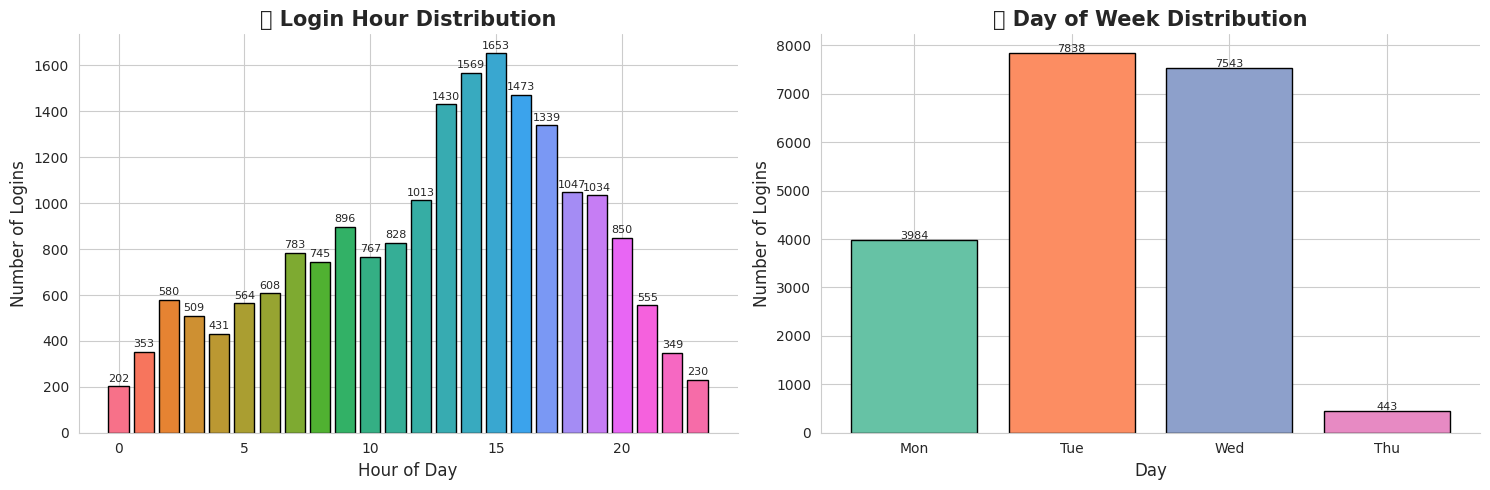

In [20]:


# Step 1: Frequency tables
print("Hour Distribution:")
display(df["hour"].value_counts().sort_index().to_frame("Count"))

print("\nDay of Week Distribution:")
display(df["day_of_week"].value_counts().sort_index().to_frame("Count"))

# Step 2: Styling
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ---------------- Hour Chart ----------------
hour_counts = df["hour"].value_counts().sort_index()
hour_colors = sns.color_palette("husl", len(hour_counts))

bars1 = axes[0].bar(
    hour_counts.index,
    hour_counts.values,
    color=hour_colors,
    edgecolor="black"
)

axes[0].set_title("⏰ Login Hour Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Logins")

for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        h + 20,
        f"{int(h)}",
        ha="center",
        fontsize=8
    )

# ---------------- Day Chart ----------------
day_counts = df["day_of_week"].value_counts().sort_index()
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][:len(day_counts)]
day_colors = sns.color_palette("Set2", len(day_counts))

bars2 = axes[1].bar(
    day_labels,
    day_counts.values,
    color=day_colors,
    edgecolor="black"
)

axes[1].set_title("📅 Day of Week Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Number of Logins")

for bar in bars2:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        h + 20,
        f"{int(h)}",
        ha="center",
        fontsize=8
    )

# Step 3: Clean look
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Cell 8D — Remove Zero-Variance Features

## Objective
This cell identifies and removes features that contain only one unique value across all rows.

## Why This Step Is Important
A zero-variance feature has no changing information, so it cannot help the model learn patterns or make predictions.

## Examples
If a column contains only:
- all zeros  
- all ones  
- same text value in every row  

then it provides no predictive value.

## Benefit
- cleaner feature set  
- reduced noise  
- faster training  
- improved model efficiency

In [21]:
# ==========================================
# CELL 8D: Remove Zero-Variance Features
# ==========================================

# Step 1: Store constant columns
zero_var_cols = []

# Step 2: Check unique values in each column
for col in df.columns:
    if df[col].nunique(dropna=False) <= 1:
        zero_var_cols.append(col)
# Column added if only one unique value exists

# Step 3: Show detected columns
print("Zero-Variance Columns:", zero_var_cols)

# Step 4: Remove useless features
df = df.drop(columns=zero_var_cols)

# Step 5: Show updated dataset shape
print("Updated Shape:", df.shape)

Zero-Variance Columns: ['is_weekend']
Updated Shape: (19808, 15)


# Cell 9A — Extract IP Network Prefix Feature

## Objective
This cell extracts the first octet of the IP address and creates a new numeric feature called `ip_octet1`.

## Why This Step Is Important
Instead of using the full IP address, the first octet provides a privacy-friendly network signal that helps group similar network ranges.

## Feature Created
- **ip_octet1** → first part of IP address (0 to 255)

## Example
IP Address: `192.168.1.10`  
Extracted Feature: `192`

## Benefits
- captures coarse network identity  
- useful for anomaly detection  
- avoids storing full IP address

In [22]:
# ==========================================
# CELL 9A: Extract Network Prefix Feature
# ==========================================

# Step 1: Extract first octet from IP address
df["ip_octet1"] = (
    df["IP Address"]
    .astype(str)
    .str.split(".")
    .str[0]
)
# Example: 192.168.1.10 -> 192

# Step 2: Convert to numeric
df["ip_octet1"] = pd.to_numeric(
    df["ip_octet1"],
    errors="coerce"
)
# Invalid values become NaN

# Step 3: Check missing values
print("Missing ip_octet1 values:")
print(df["ip_octet1"].isnull().sum())

# Step 4: Preview result
display(df[["IP Address", "ip_octet1"]].head())

Missing ip_octet1 values:
0


,IP Address,ip_octet1
0,209.236.117.142,209
1,10.0.0.89,10
2,209.236.123.147,209
3,38.135.39.107,38
4,193.242.213.164,193


# Cell 9B — Network Feature Visualization

## Objective
This cell visually analyzes important network-based features used in the Zero Trust model.

## Features Visualized
- **Round-Trip Time [ms]** → network latency behavior  
- **ASN** → autonomous system / ISP identifier  
- **ip_octet1** → coarse IP network prefix

## Why This Step Is Important
Network characteristics often reveal suspicious login behavior. Visual analysis helps understand patterns, outliers, and dominant ranges.

## Design Goals
- colorful charts  
- clean academic styling  
- easy comparison  
- presentation-ready visuals

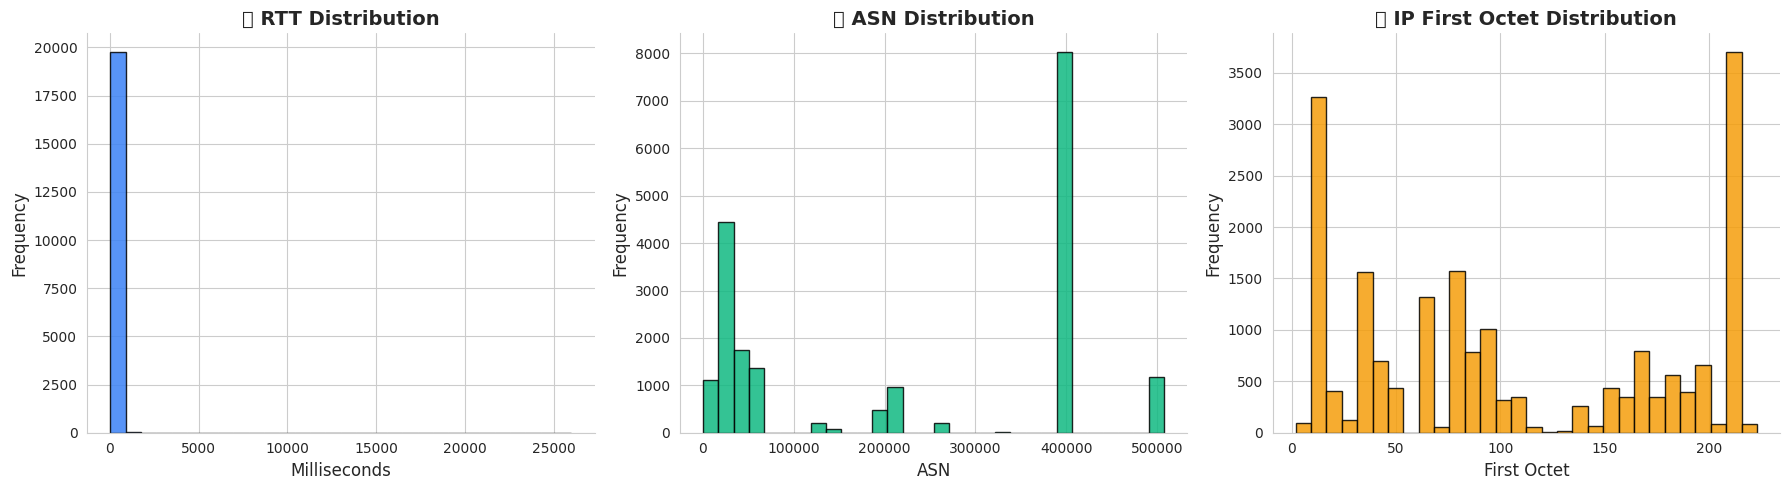

In [23]:
# ==========================================
# CELL 9B: Beautiful Network Feature Charts
# ==========================================

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# -------- RTT Distribution --------
axes[0].hist(
    df["Round-Trip Time [ms]"],
    bins=30,
    color="#3B82F6",
    edgecolor="black",
    alpha=0.85
)
axes[0].set_title("🌐 RTT Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Milliseconds")
axes[0].set_ylabel("Frequency")

# -------- ASN Distribution --------
axes[1].hist(
    df["ASN"],
    bins=30,
    color="#10B981",
    edgecolor="black",
    alpha=0.85
)
axes[1].set_title("🏢 ASN Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("ASN")
axes[1].set_ylabel("Frequency")

# -------- IP Octet Distribution --------
axes[2].hist(
    df["ip_octet1"].dropna(),
    bins=30,
    color="#F59E0B",
    edgecolor="black",
    alpha=0.85
)
axes[2].set_title("📡 IP First Octet Distribution", fontsize=14, fontweight="bold")
axes[2].set_xlabel("First Octet")
axes[2].set_ylabel("Frequency")

# Clean borders
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Cell 10A — Country Feature Encoding

## Objective
This cell converts the categorical `Country` column into a binary numeric feature suitable for machine learning.

## Why This Step Is Important
Machine learning models require numeric inputs. Raw text categories such as country names must be encoded before training.

## Encoding Strategy
- **Country_IN = 1** → Login from India  
- **Country_IN = 0** → Login from any other country

## Why Binary Encoding?
This simplifies the feature into a practical security signal:

- domestic login  
- foreign login

## Outputs Generated
1. Top country frequencies  
2. Encoded country distribution  
3. Removal of original text column

In [24]:
# ==========================================
# CELL 10A: Encode Country Feature
# ==========================================

# Step 1: View most common countries
print("Top Countries:")
display(df["Country"].value_counts().head(10).to_frame("Count"))

# Step 2: Create binary feature
df["Country_IN"] = (df["Country"] == "IN").astype(int)
# 1 = India, 0 = Other countries

# Step 3: Show encoded distribution
print("\nEncoded Country Distribution:")
display(df["Country_IN"].value_counts().to_frame("Count"))

# Step 4: Remove original text column
df = df.drop(columns=["Country"])

Top Countries:


,Count
Country,
US,8725
NO,5811
PL,1209
BR,627
IN,348
ID,311
GB,309
AU,306
RO,304



Encoded Country Distribution:


,Count
Country_IN,
0,19460
1,348


# Cell 10B — Browser Feature Engineering

## Objective
This cell transforms raw browser information into clean numeric features for machine learning.

## Why This Step Is Important
The original browser column contains text with version numbers, which is not directly usable by models. We simplify browser names and convert them into binary columns.

## Process Performed
1. Remove version numbers  
2. Group browsers into categories  
3. Apply one-hot encoding  
4. Remove raw text columns

## Final Browser Features
- **browser_Chrome**
- **browser_Edge**
- **browser_Other**

## Benefit
Browser type can indicate familiar or unusual device behavior during login attempts.

In [25]:
# ==========================================
# CELL 10B: Browser Feature Engineering
# ==========================================

# Step 1: Extract browser name only
df["browser_name"] = (
    df["Browser Name and Version"]
    .astype(str)
    .str.replace(r"\s*\d+.*", "", regex=True)
)
# Example: Chrome 120.0 -> Chrome

# Step 2: Simplify browser groups
def map_browser(browser):
    b = browser.lower()

    if "chrome" in b or "chromium" in b:
        return "Chrome"
    elif "edge" in b:
        return "Edge"
    else:
        return "Other"

# Step 3: Apply grouping
df["browser_simple"] = df["browser_name"].apply(map_browser)

# Step 4: Show category counts
print("Browser Categories:")
display(df["browser_simple"].value_counts().to_frame("Count"))

# Step 5: One-hot encode categories
browser_dummies = pd.get_dummies(
    df["browser_simple"],
    prefix="browser"
).astype(int)

# Step 6: Merge encoded columns
df = pd.concat([df, browser_dummies], axis=1)

# Step 7: Remove raw text columns
df = df.drop(columns=[
    "Browser Name and Version",
    "browser_name",
    "browser_simple"
])

# Step 8: Show updated shape
print("Updated Shape:", df.shape)

Browser Categories:


,Count
browser_simple,
Chrome,13893
Other,5695
Edge,220


Updated Shape: (19808, 18)


# Cell 11A — Remove Leakage and Irrelevant Columns

## Objective
This cell removes columns that should not be used for model training because they are identifiers, redundant raw fields, or sources of target leakage.

## Why This Step Is Important
Some columns can unfairly reveal the answer or add no predictive value. Keeping them may inflate model performance and reduce real-world reliability.

## Types of Columns Removed

### 1. Identifier Columns
- **User ID**  
Used only to identify users, not behavior.

### 2. Raw Source Columns Already Engineered
- **IP Address**  
Already transformed into `ip_octet1`

- **Login Timestamp**  
Already transformed into time features

### 3. Leakage Columns
- **Login Successful**
- **Is Attack IP**
- **Is Account Takeover**

These are directly related to the target label and must not be used as inputs.

## Benefits
- prevents data leakage  
- improves fairness  
- cleaner feature set  
- realistic model evaluation

In [26]:
# ==========================================
# CELL 11A: Remove Leakage & Irrelevant Columns
# ==========================================

# Step 1: Define columns to remove
drop_cols = [
    "User ID",
    "IP Address",
    "Login Timestamp",
    "Login Successful",
    "Is Attack IP",
    "Is Account Takeover"
]

# Step 2: Keep only existing columns
existing = [col for col in drop_cols if col in df.columns]

# Step 3: Drop selected columns
df = df.drop(columns=existing)

# Step 4: Show removed columns
print("Dropped Columns:")
print(existing)

# Step 5: Show updated dataset info
print("\nUpdated Shape:", df.shape)
display(pd.DataFrame({"Remaining Columns": df.columns}))

Dropped Columns:
['User ID', 'IP Address', 'Login Timestamp', 'Login Successful', 'Is Attack IP', 'Is Account Takeover']

Updated Shape: (19808, 12)


,Remaining Columns
0,Round-Trip Time [ms]
1,ASN
2,User Agent String
3,OS Name and Version
4,attack_label
5,hour
6,day_of_week
7,ip_octet1
8,Country_IN
9,browser_Chrome


# Cell 11B — Create Feature Matrix (X) and Target Vector (y)

## Objective
This cell separates the dataset into input features and target labels for machine learning.

## Why This Step Is Important
Supervised learning models require:

- **X** → independent variables (features)  
- **y** → dependent variable (target label)

The model learns patterns in `X` to predict `y`.

## Definitions
- **X** = all predictor columns  
- **y** = `attack_label`

## Outputs Generated
1. Shape of feature matrix  
2. Shape of target vector  
3. List of final features  
4. Target class distribution

In [27]:
# ==========================================
# CELL 11B: Create X and y
# ==========================================

X = df.drop(columns=["attack_label"])
y = df["attack_label"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
display(pd.DataFrame({"Features": X.columns}))

print("\nTarget Distribution:")
display(y.value_counts().to_frame("Count"))

Feature Matrix Shape: (19808, 11)
Target Shape: (19808,)

Feature Columns:


,Features
0,Round-Trip Time [ms]
1,ASN
2,User Agent String
3,OS Name and Version
4,hour
5,day_of_week
6,ip_octet1
7,Country_IN
8,browser_Chrome
9,browser_Edge



Target Distribution:


,Count
attack_label,
1,9904
0,9904


# Cell 11C — Remove Remaining Raw Text Columns

## Objective
This cell removes any remaining raw text-based columns from the feature matrix `X`.

## Why This Step Is Important
Most machine learning models used in this project require numeric inputs. Unprocessed text columns can cause training errors and reduce model consistency.

## Columns Removed
- **User Agent String**  
Detailed browser/device string with high variability

- **OS Name and Version**  
Operating system text with version details

## Why Remove Them?
These fields were not encoded in this pipeline and are better excluded than used in raw form.

## Outputs Generated
1. Removed columns list  
2. Updated feature shape  
3. Final feature list  
4. Verified target distribution

In [28]:
# ==========================================
# CELL 11C: Clean Remaining Raw Columns
# ==========================================

extra_drop = [
    "User Agent String",
    "OS Name and Version"
]

existing = [col for col in extra_drop if col in X.columns]
X = X.drop(columns=existing)

print("Dropped Extra Raw Columns:", existing)

print("\nUpdated Feature Shape:", X.shape)

print("\nFinal Feature Columns:")
display(pd.DataFrame({"Features": X.columns}))

print("\nCorrect Target Distribution:")
display(y.value_counts().sort_index().to_frame("Count"))

Dropped Extra Raw Columns: ['User Agent String', 'OS Name and Version']

Updated Feature Shape: (19808, 9)

Final Feature Columns:


,Features
0,Round-Trip Time [ms]
1,ASN
2,hour
3,day_of_week
4,ip_octet1
5,Country_IN
6,browser_Chrome
7,browser_Edge
8,browser_Other



Correct Target Distribution:


,Count
attack_label,
0,9904
1,9904


# Cell 12A — Train/Test Split

## Objective
This cell divides the dataset into training and testing subsets for model development and evaluation.

## Why This Step Is Important
A machine learning model must be evaluated on unseen data. Splitting the dataset helps measure how well the model generalizes to new login attempts.

## Split Configuration
- **80% Training Data** → used to learn patterns  
- **20% Testing Data** → used for final evaluation  

## Why Use Stratification?
`stratify=y` preserves the class ratio in both sets, ensuring balanced representation of normal and attack records.

## Outputs Generated
1. Training set shape  
2. Testing set shape  
3. Training target distribution  
4. Testing target distribution

In [29]:
# ==========================================
# CELL 12A: Train/Test Split
# ==========================================

# Step 1: Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 2: Show dataset shapes
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# Step 3: Show class balance in training set
print("\nTrain Target Ratio:")
display(y_train.value_counts().sort_index().to_frame("Count"))

# Step 4: Show class balance in testing set
print("\nTest Target Ratio:")
display(y_test.value_counts().sort_index().to_frame("Count"))

Train Shape: (15846, 9)
Test Shape : (3962, 9)

Train Target Ratio:


,Count
attack_label,
0,7923
1,7923



Test Target Ratio:


,Count
attack_label,
0,1981
1,1981


# Cell 12B — Feature Scaling

## Objective
This cell standardizes numerical feature values using `StandardScaler`.

## Why This Step Is Important
Features may have very different ranges. For example:

- RTT may be in hundreds  
- ASN may be in thousands  
- Binary features are only 0 or 1  

Large-scale differences can negatively affect some algorithms such as Logistic Regression.

## Scaling Method
Standardization transforms each feature as:

\[
z = \frac{x - \mu}{\sigma}
\]

Where:
- \(x\) = original value  
- \(\mu\) = mean  
- \(\sigma\) = standard deviation

## Important Note
The scaler is fitted only on training data to prevent data leakage.

## Outputs Generated
1. Scaled train shape  
2. Scaled test shape  
3. Validation for NaN values  
4. Validation for infinite values

In [30]:
# ==========================================
# CELL 12B: Feature Scaling
# ==========================================

# Step 1: Initialize scaler
scaler = StandardScaler()

# Step 2: Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Step 3: Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

# Step 4: Show shapes
print("Scaled Train Shape:", X_train_scaled.shape)
print("Scaled Test Shape :", X_test_scaled.shape)

# Step 5: Validate output quality
print("\nNaN Values in Scaled Train:", np.isnan(X_train_scaled).sum())
print("Inf Values in Scaled Train:", np.isinf(X_train_scaled).sum())

Scaled Train Shape: (15846, 9)
Scaled Test Shape : (3962, 9)

NaN Values in Scaled Train: 0
Inf Values in Scaled Train: 0


# Cell 13A — Logistic Regression Training

## Objective
This cell trains a Logistic Regression model as a baseline classifier.

## Why This Step Is Important
Logistic Regression is a strong and interpretable benchmark model. It helps compare whether more advanced models truly provide better performance.

## Model Configuration

- **max_iter = 1000**  
Increases training iterations to ensure convergence.

- **class_weight = "balanced"**  
Automatically adjusts class weights based on label frequencies.

- **random_state = 42**  
Ensures reproducible results.

## Why Use This Model?
- fast training  
- interpretable coefficients  
- strong baseline for binary classification

In [31]:
# ==========================================
# CELL 13A: Logistic Regression Training
# ==========================================

# Step 1: Initialize model
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Step 2: Train model
lr.fit(X_train_scaled, y_train)

# Step 3: Confirm success
print(" Logistic Regression trained successfully")

 Logistic Regression trained successfully


# Cell 13B — Logistic Regression Evaluation

## Objective
This cell evaluates the trained Logistic Regression model using classification metrics, ROC-AUC score, and a confusion matrix.

## Why This Step Is Important
Model evaluation helps measure how well the classifier distinguishes between normal and attack logins on unseen test data.

## Metrics Used

### Classification Report
Provides:
- Precision  
- Recall  
- F1-score  
- Support  

### ROC-AUC Score
Measures ranking quality of predicted probabilities.

### Confusion Matrix
Shows:
- True Positives  
- True Negatives  
- False Positives  
- False Negatives

## Output Goal
Establish a strong baseline before testing advanced models.

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.77      0.77      1981
           1       0.77      0.77      0.77      1981

    accuracy                           0.77      3962
   macro avg       0.77      0.77      0.77      3962
weighted avg       0.77      0.77      0.77      3962

ROC-AUC Score: 0.8105


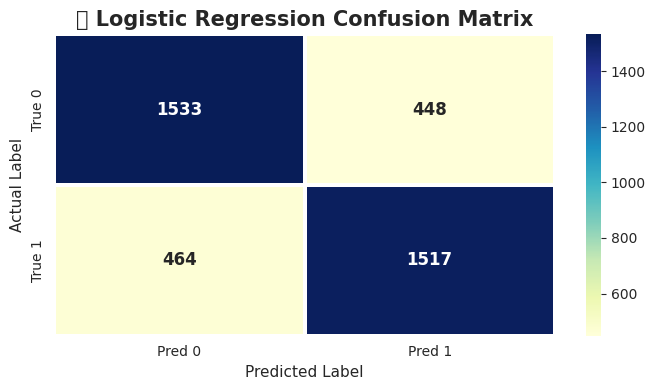

In [33]:
# ==========================================
# CELL 13B: Logistic Regression Evaluation
# ==========================================

# Step 1: Generate predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Step 2: Print metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Step 3: ROC-AUC score
roc_lr = roc_auc_score(y_test, y_prob_lr)
print("ROC-AUC Score:", round(roc_lr, 4))

# Step 4: Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Step 5: Colorful heatmap
plt.figure(figsize=(7,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=1.5,
    linecolor="white",
    cbar=True,
    annot_kws={"size":12, "weight":"bold"},
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.title("📘 Logistic Regression Confusion Matrix", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)
plt.tight_layout()
plt.show()

# Cell 14A — Random Forest Training

## Objective
This cell trains a Random Forest classifier, a powerful ensemble model used as the main predictive model in this project.

## Why This Step Is Important
Random Forest can capture nonlinear patterns and interactions between features, making it highly effective for login risk detection.

## Model Configuration

- **n_estimators = 300**  
Number of decision trees in the forest.

- **max_depth = None**  
Trees can grow fully unless stopped by other rules.

- **min_samples_split = 2**  
Minimum samples needed to split a node.

- **min_samples_leaf = 1**  
Minimum samples required at a leaf node.

- **class_weight = "balanced"**  
Adjusts learning weight for both classes.

- **random_state = 42**  
Ensures reproducible results.

- **n_jobs = -1**  
Uses all CPU cores for faster training.

## Why Use Random Forest?
- strong predictive power  
- handles mixed features well  
- robust to noise  
- provides feature importance

In [35]:
# ==========================================
# CELL 14A: Random Forest Training
# ==========================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print(" Random Forest trained successfully")

 Random Forest trained successfully


# Cell 14B — Random Forest Evaluation

## Objective
This cell evaluates the trained Random Forest model using classification metrics, ROC-AUC score, and a confusion matrix.

## Why This Step Is Important
This step measures how accurately the Random Forest model detects normal and attack logins on unseen test data.

## Metrics Used
- Precision  
- Recall  
- F1-score  
- ROC-AUC  
- Confusion Matrix

## Expected Outcome
Compare Random Forest performance against Logistic Regression and identify the stronger final model.

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1981
           1       0.94      0.93      0.93      1981

    accuracy                           0.93      3962
   macro avg       0.93      0.93      0.93      3962
weighted avg       0.93      0.93      0.93      3962

ROC-AUC Score: 0.9805


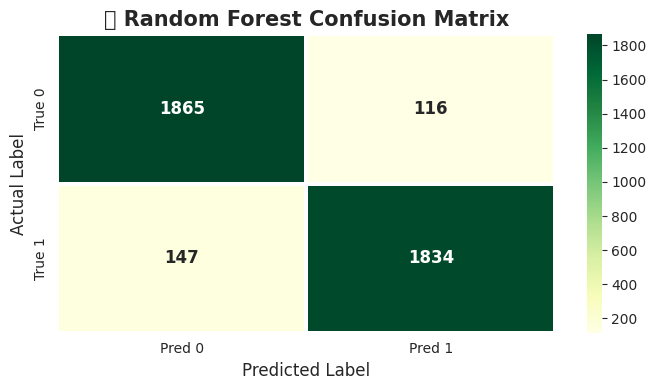

In [36]:
# ==========================================
# CELL 14B: Random Forest Evaluation
# ==========================================

# Step 1: Generate predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Step 2: Print report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Step 3: ROC-AUC score
roc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC Score:", round(roc_rf, 4))

# Step 4: Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Step 5: Beautiful heatmap
plt.figure(figsize=(7,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    linewidths=1.5,
    linecolor="white",
    cbar=True,
    annot_kws={"size":12, "weight":"bold"},
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.title("🌳 Random Forest Confusion Matrix", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Model Comparison — Classification Performance

## Objective
This chart compares the performance of Logistic Regression and Random Forest using three important metrics:

- Precision  
- Recall  
- F1-Score  

## Why This Step Is Important
It visually demonstrates which model performs better and supports final model selection.

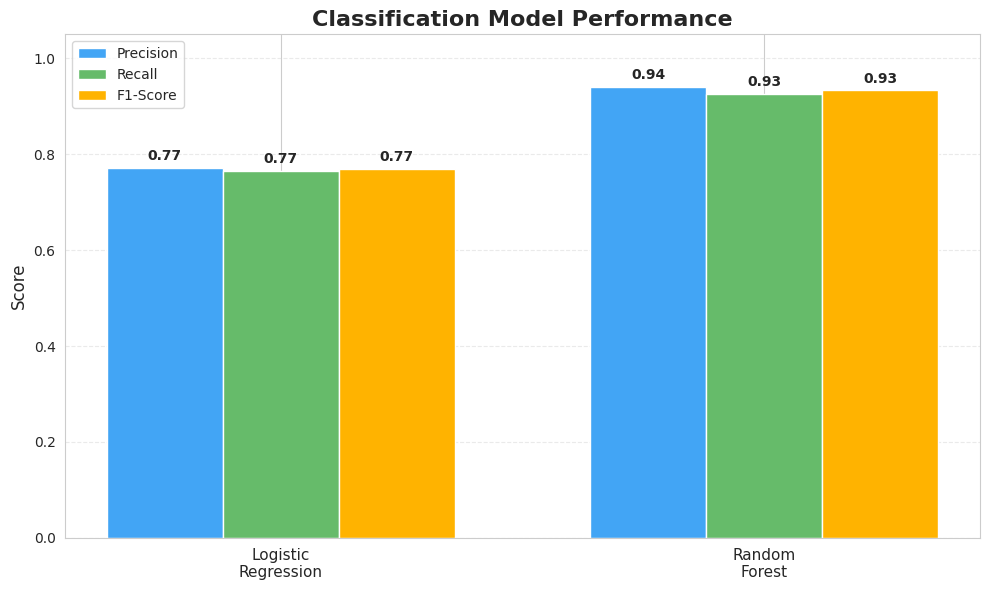

In [37]:
# ==========================================
# MODEL COMPARISON: CLASSIFICATION PERFORMANCE
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score

# Step 1: Calculate metrics for Logistic Regression
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Step 2: Calculate metrics for Random Forest
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Step 3: Store values
models = ["Logistic\nRegression", "Random\nForest"]
precision_vals = [lr_precision, rf_precision]
recall_vals = [lr_recall, rf_recall]
f1_vals = [lr_f1, rf_f1]

x = np.arange(len(models))
width = 0.24

# Step 4: Create chart
plt.figure(figsize=(10,6))
bars1 = plt.bar(x - width, precision_vals, width, label="Precision", color="#42A5F5")
bars2 = plt.bar(x, recall_vals, width, label="Recall", color="#66BB6A")
bars3 = plt.bar(x + width, f1_vals, width, label="F1-Score", color="#FFB300")

# Step 5: Labels and title
plt.title("Classification Model Performance", fontsize=16, fontweight="bold")
plt.ylabel("Score")
plt.xticks(x, models, fontsize=11)
plt.ylim(0, 1.05)
plt.legend()

# Step 6: Add values on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Step 7: Grid and clean look
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Cell 15A — Random Forest Feature Importance

## Objective
This cell explains which features contributed the most to Random Forest predictions.

## Why This Step Is Important
Feature importance improves model interpretability by showing which login signals were most influential in risk detection.

## What It Tells Us
Higher importance means the feature was used more effectively across decision trees.

## Typical High-Value Features
- ASN  
- ip_octet1  
- hour  
- network latency

,Feature,Importance
1,ASN,0.517913
4,ip_octet1,0.359083
2,hour,0.079650
3,day_of_week,0.019945
0,Round-Trip Time [ms],0.007594
5,Country_IN,0.005788
6,browser_Chrome,0.004717
8,browser_Other,0.004201
7,browser_Edge,0.001108


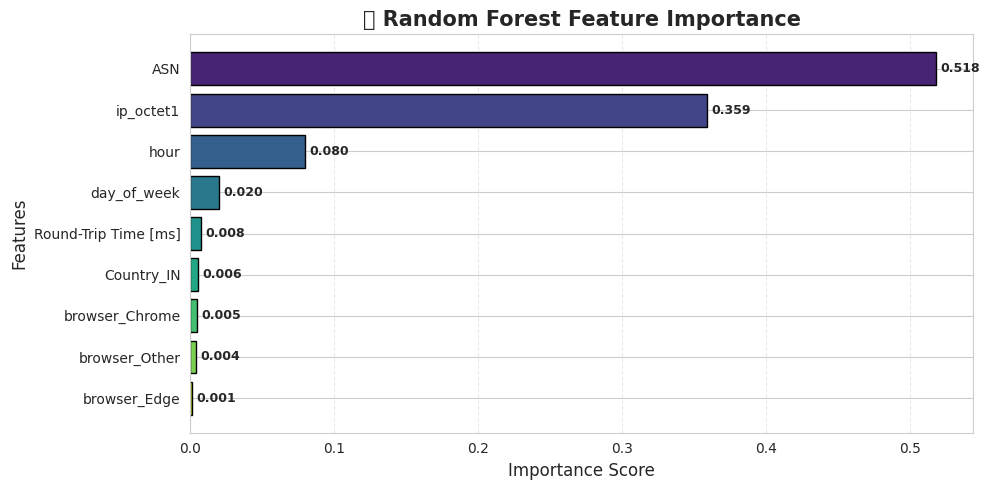

In [38]:
# ==========================================
# CELL 15A: Random Forest Feature Importance
# ==========================================

# Step 1: Create importance table
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

# Step 2: Display table
display(importance_df)

# Step 3: Create colorful chart
plt.figure(figsize=(10,5))

colors = sns.color_palette("viridis", len(importance_df))

bars = plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color=colors,
    edgecolor="black"
)

# Step 4: Add values on bars
for bar in bars:
    w = bar.get_width()
    plt.text(
        w + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{w:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# Step 5: Labels and style
plt.gca().invert_yaxis()
plt.title("🌳 Random Forest Feature Importance", fontsize=15, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Cell 15B — Probability Calibration

## Objective
This cell improves the probability outputs of the Random Forest model using calibration.

## Why This Step Is Important
Some models classify well but produce poorly scaled probabilities. Calibration makes risk scores more meaningful for decision thresholds such as:

- ALLOW  
- MFA  
- BLOCK  

## Method Used
**Isotonic Calibration**

A non-parametric technique that adjusts predicted probabilities to better match real outcomes.

## Benefits
- better risk score interpretation  
- improved threshold decisions  
- production-ready probabilities

## Outputs Generated
1. Calibrated ROC-AUC  
2. Minimum risk score  
3. Maximum risk score  
4. Mean risk score

In [39]:
# ==========================================
# CELL 15B: Probability Calibration
# ==========================================

# Step 1: Initialize calibrated model
cal_rf = CalibratedClassifierCV(
    estimator=rf,
    method="isotonic",
    cv=3
)

# Step 2: Fit calibration model
cal_rf.fit(X_train, y_train)

# Step 3: Predict calibrated probabilities
y_prob_cal = cal_rf.predict_proba(X_test)[:, 1]

# Step 4: Evaluate ROC-AUC
roc_cal = roc_auc_score(y_test, y_prob_cal)
print("Calibrated ROC-AUC:", round(roc_cal, 4))

# Step 5: Show risk score range
print("Risk Score Range:")
print("Min :", round(y_prob_cal.min(), 4))
print("Max :", round(y_prob_cal.max(), 4))
print("Mean:", round(y_prob_cal.mean(), 4))

Calibrated ROC-AUC: 0.9804
Risk Score Range:
Min : 0.0163
Max : 0.998
Mean: 0.5001


Chosen Thresholds
ALLOW < 0.2
MFA   : 0.2 to 0.8
BLOCK >= 0.8

Decision Distribution:


,Count
ALLOW,1792
BLOCK,1699
MFA,471


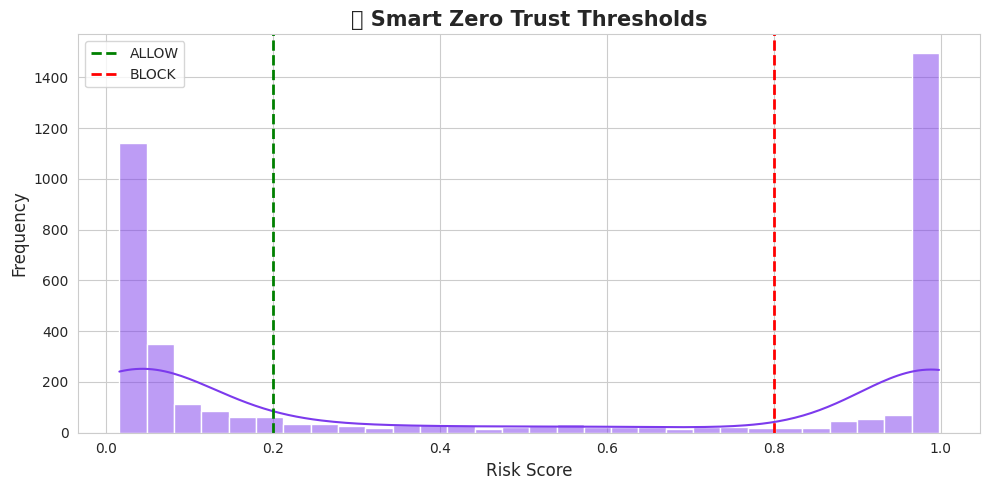

In [41]:
# ==========================================
# SMART ZERO TRUST THRESHOLDS
# ==========================================

allow_threshold = 0.20
block_threshold = 0.80

def smart_decision(risk):
    if risk < allow_threshold:
        return "ALLOW"
    elif risk < block_threshold:
        return "MFA"
    return "BLOCK"

smart_results = pd.Series(y_prob_cal).apply(smart_decision)

print("Chosen Thresholds")
print("ALLOW <", allow_threshold)
print("MFA   :", allow_threshold, "to", block_threshold)
print("BLOCK >=", block_threshold)

print("\nDecision Distribution:")
display(smart_results.value_counts().to_frame("Count"))

# Beautiful chart
plt.figure(figsize=(10,5))
sns.histplot(y_prob_cal, bins=30, kde=True, color="#7C3AED")

plt.axvline(allow_threshold, color="green", linestyle="--", linewidth=2, label="ALLOW")
plt.axvline(block_threshold, color="red", linestyle="--", linewidth=2, label="BLOCK")

plt.title("🎯 Smart Zero Trust Thresholds", fontsize=15, fontweight="bold")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Cell 16B — Zero Trust Decision Visualization

## Objective
This cell visualizes the final Zero Trust decisions generated from calibrated risk scores.

## Why This Step Is Important
A visual summary helps explain how many login attempts were:

- Allowed  
- Sent for MFA  
- Blocked  

This is useful for reports, demos, and presentations.

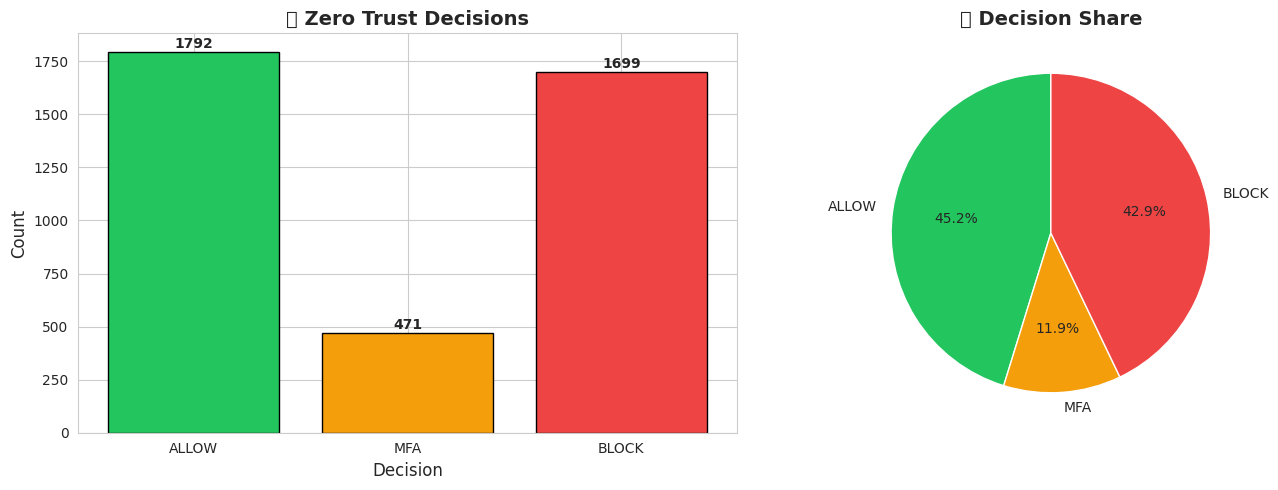

In [42]:
# ==========================================
# CELL 16B: Zero Trust Decision Visualization
# ==========================================

# Count decisions
decision_counts = smart_results.value_counts()

# Desired order
decision_counts = decision_counts.reindex(["ALLOW", "MFA", "BLOCK"])

# Colors
colors = ["#22C55E", "#F59E0B", "#EF4444"]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# -------- Bar Chart --------
bars = axes[0].bar(
    decision_counts.index,
    decision_counts.values,
    color=colors,
    edgecolor="black"
)

axes[0].set_title("🛡️ Zero Trust Decisions", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Decision")
axes[0].set_ylabel("Count")

for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        h + 20,
        f"{int(h)}",
        ha="center",
        fontweight="bold"
    )

# -------- Pie Chart --------
axes[1].pie(
    decision_counts.values,
    labels=decision_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor":"white"}
)

axes[1].set_title("📊 Decision Share", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [43]:


def zero_trust_decision(risk):
    if risk < 0.20:
        return "ALLOW"
    elif risk < 0.80:
        return "MFA"
    else:
        return "BLOCK"

decisions = pd.Series(y_prob_cal).apply(zero_trust_decision)

print("Decision Distribution:")
display(decisions.value_counts().to_frame("Count"))

Decision Distribution:


,Count
ALLOW,1792
BLOCK,1699
MFA,471


In [44]:
# ==========================================
# CELL 17A: Save Final Production Artifacts
# ==========================================

MODEL_PATH = os.path.join(MODEL_DIR, "zta_calibrated_rf.pkl")
SCALER_PATH = os.path.join(MODEL_DIR, "zta_scaler.pkl")
FEATURES_PATH = os.path.join(MODEL_DIR, "zta_feature_columns.pkl")

joblib.dump(cal_rf, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(X.columns.tolist(), FEATURES_PATH)

print("✅ Files saved successfully")
print(MODEL_PATH)
print(SCALER_PATH)
print(FEATURES_PATH)

✅ Files saved successfully
/content/drive/MyDrive/zta_models/zta_calibrated_rf.pkl
/content/drive/MyDrive/zta_models/zta_scaler.pkl
/content/drive/MyDrive/zta_models/zta_feature_columns.pkl


In [45]:
# ==========================================
# CELL 17B: Reload Model and Test Prediction
# ==========================================

loaded_model = joblib.load(MODEL_PATH)
loaded_features = joblib.load(FEATURES_PATH)

print("Loaded Features:")
print(loaded_features)

sample_pred = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]

print("\nSample Risk Scores:")
print(np.round(sample_pred, 4))

Loaded Features:
['Round-Trip Time [ms]', 'ASN', 'hour', 'day_of_week', 'ip_octet1', 'Country_IN', 'browser_Chrome', 'browser_Edge', 'browser_Other']

Sample Risk Scores:
[0.9961 0.0257 0.0163 0.0296 0.9817]


In [46]:
# ==========================================
# CELL 17C: Scenario Testing for Decisions
# ==========================================

def decide(risk):
    if risk < 0.30:
        return "ALLOW"
    elif risk < 0.70:
        return "MFA"
    return "BLOCK"

# Manual scenarios
test_cases = pd.DataFrame([
    # likely safe
    [50, 24560, 10, 1, 80, 1, 1, 0, 0],

    # moderate risk
    [180, 60000, 2, 3, 150, 0, 1, 0, 0],

    # another moderate
    [250, 120000, 23, 2, 200, 0, 0, 0, 1],

    # high risk
    [500, 390000, 3, 0, 220, 0, 0, 0, 1],

    # high risk
    [700, 500000, 1, 1, 209, 0, 0, 1, 0],
], columns=X.columns)

# Predict
risks = cal_rf.predict_proba(test_cases)[:, 1]
test_cases["risk_score"] = np.round(risks, 4)
test_cases["decision"] = [decide(r) for r in risks]

display(test_cases)

,Round-Trip Time [ms],ASN,hour,day_of_week,ip_octet1,Country_IN,browser_Chrome,browser_Edge,browser_Other,risk_score,decision
0,50,24560,10,1,80,1,1,0,0,0.0539,ALLOW
1,180,60000,2,3,150,0,1,0,0,0.5248,MFA
2,250,120000,23,2,200,0,0,0,1,0.1953,ALLOW
3,500,390000,3,0,220,0,0,0,1,0.7758,BLOCK
4,700,500000,1,1,209,0,0,1,0,0.9645,BLOCK
